In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path
from statistics import mean
import matplotlib.pyplot as plt
import json

In [2]:
# ------------------------------- setting start ------------------------------ #
# color
color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
errorbar_color = "#3A3A3A"

# font
csfont = {'family':'Times New Roman', 'serif': 'Times' , 'size' : 23}
plt.rc('text', usetex=True)
plt.rc('font', **csfont)

# markers
markers=["o","*","^","D"]
linestyles = ['-', '--', '-.', ':']

# Ref: https://blog.csdn.net/Strive_For_Future/article/details/118755312

# bar plot size
bar_width = 0.4
bar_btw_space = 0.04
bar_space = 0.2

# errorbar plot size
err_lw=1.5
err_capsize=4
err_capthick=1.5

# set fig size
figsize=(6.4, 4.8)
# -------------------------------- setting end ------------------------------- #

In [3]:
base_output_dir=Path("/home/syjintw/Desktop/NUS/LapisGS-object-based-renderer/plotting/figs")
base_output_dir.mkdir(parents=True, exist_ok=True)

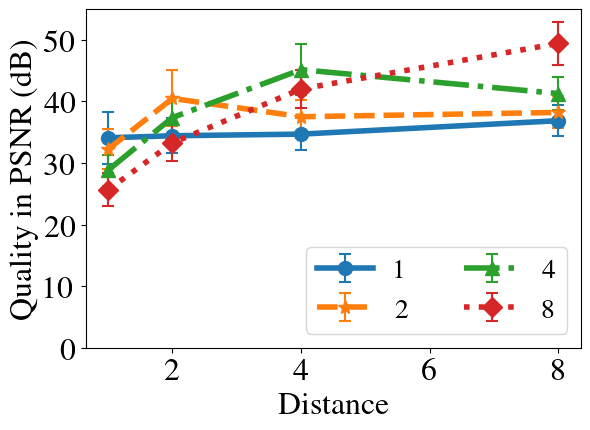

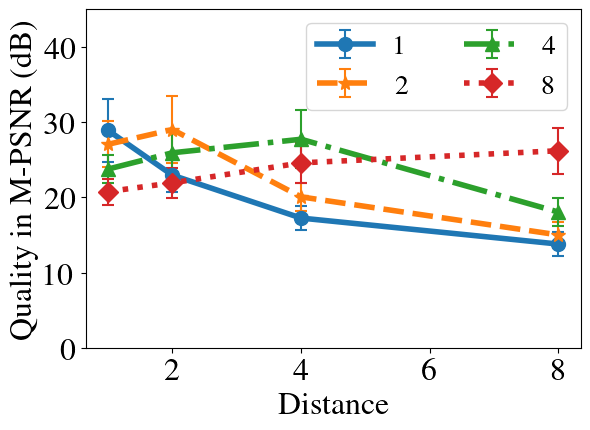

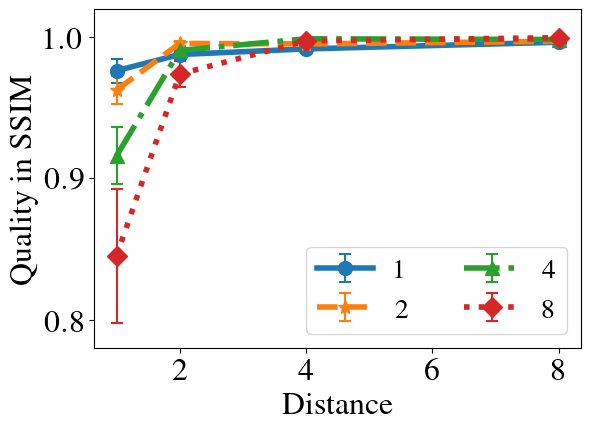

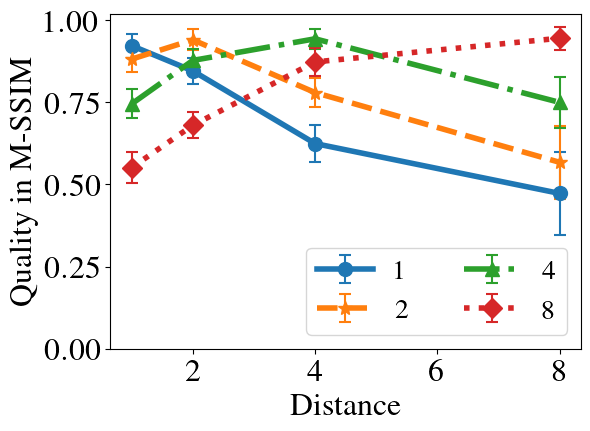

In [16]:
def gs_res_in_diff_dist_line_plot():
    saveDir = Path(".")/"figs"/f"gs_res_in_diff_dist"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    gs_res_list = [1, 2, 4, 8]
    cam_dist_list = [1, 2, 4, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    "SSIM_std", "MASKED_SSIM_std", 
                    "PSNR_std", "MASKED_PSNR_std", 
                    "LPIPS_std", 
                    "LOSS_std", "MASKED_LOSS_std"
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                # Iterate through items (handles cases where one file has multiple experiments)
                l = [scene_name, gs_res, render_factor, cam_dist]
                for METRICS_NAME in METRICS_LIST:
                    l.append(data["ours_30000"][METRICS_NAME])
                data_list.append(l)
    
    column_names = ["scene", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    
    # ----------------------------------- PSNR ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'PSNR'
    y_std_name = 'PSNR_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 55)
    plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------- M-PSNR ---------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_PSNR'
    y_std_name = 'MASKED_PSNR_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- SSIM ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'SSIM'
    y_std_name = 'SSIM_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0.78, 1.02)
    plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_SSIM'
    y_std_name = 'MASKED_SSIM_std'
    hue_name = 'gs_res'

    hue_list = df_plot[hue_name].unique()
    
    plt.figure(figsize=figsize)
    
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val].sort_values(x_name)
        
        x = subset[x_name]
        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        plt.errorbar(
            x, y, 
            yerr=yerr, 
            label=f'{hue_val}', # label for legend
            marker=markers[idx], markersize=10,
            linestyle=linestyles[idx], linewidth=4, 
            elinewidth=err_lw, capthick=err_capthick, capsize=err_capsize,  # Adds the little cross-bars at the ends
            color=color_palette[idx], alpha=1.0
        )
        
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # plt.xlim(0, 10)
    # plt.xticks([0, 5, 10])
    plt.ylim(0., 1.02)
    # plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()
    
gs_res_in_diff_dist_line_plot()

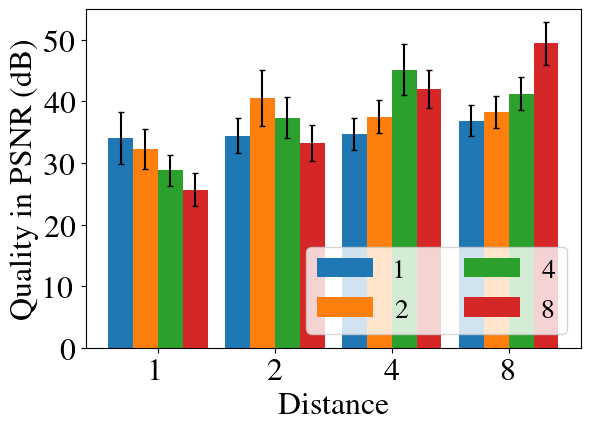

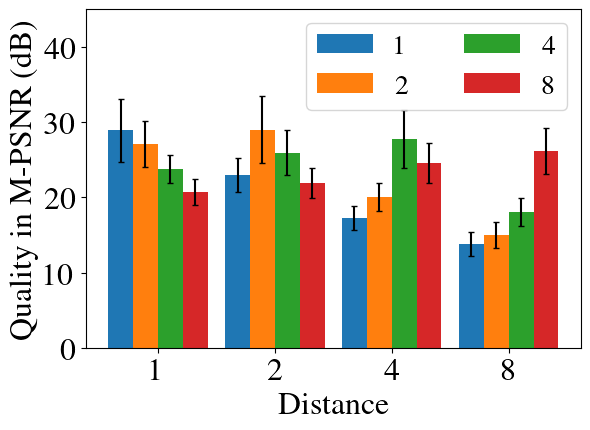

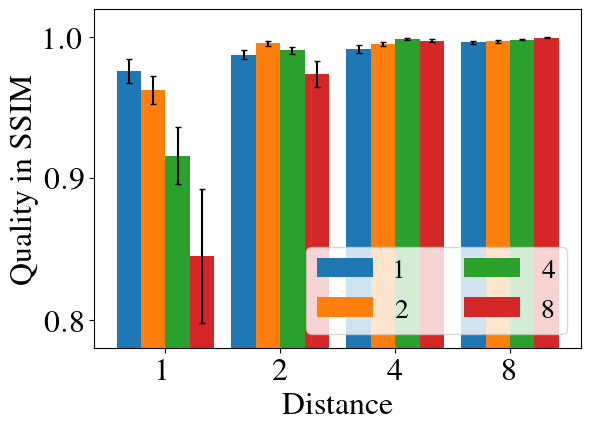

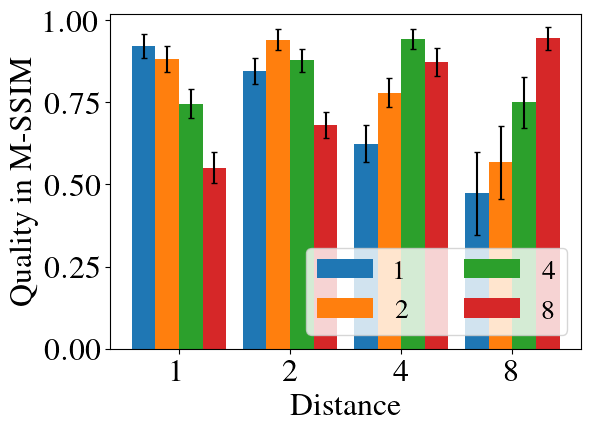

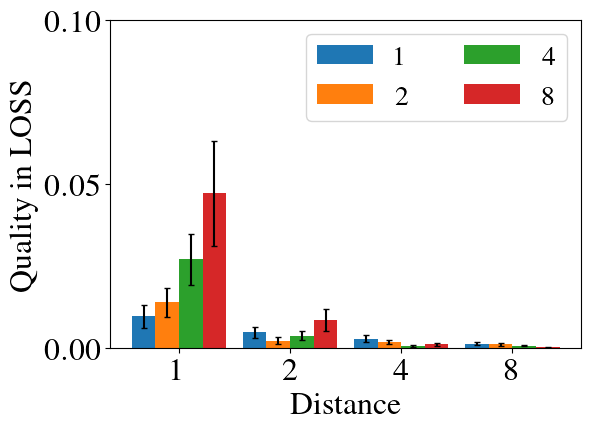

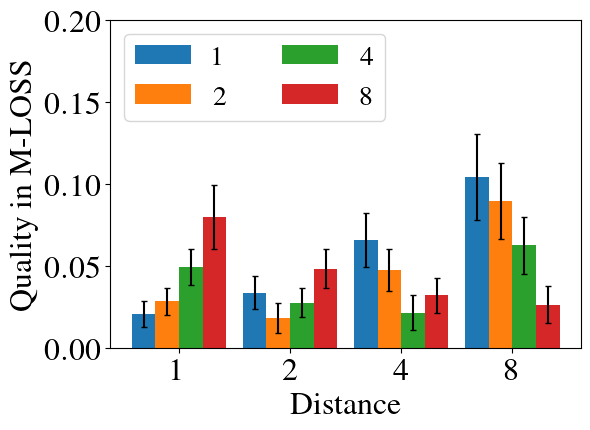

In [21]:
def gs_res_in_diff_dist_bar_plot():
    saveDir = Path(".")/"figs"/f"gs_res_in_diff_dist_bar_plot"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    scene_name = "lego"
    gs_res_list = [1, 2, 4, 8]
    cam_dist_list = [1, 2, 4, 8]
    
    # Metrics: SSIM, PSNR, MASKED_PSNR, LPIPS, LOSS, MASKED_LOSS
    METRICS_LIST = ["SSIM", "MASKED_SSIM", 
                    "PSNR", "MASKED_PSNR", 
                    "LPIPS", 
                    "LOSS", "MASKED_LOSS",
                    "SSIM_std", "MASKED_SSIM_std", 
                    "PSNR_std", "MASKED_PSNR_std", 
                    "LPIPS_std", 
                    "LOSS_std", "MASKED_LOSS_std"
                    ]
    
    data_list = []
    
    for gs_res in gs_res_list:
        for cam_dist in cam_dist_list:
            if gs_res < cam_dist:
                render_factor = 1
            else:
                # Bash 的除法本身就是 int()，會自動捨去小數
                render_factor = gs_res // cam_dist
                
            file_path = Path(f"/home/syjintw/Desktop/NUS/lapisgs-output/{scene_name}/opacity")/f"{scene_name}_res{gs_res}"/f"results_ours_{cam_dist}x_factor{render_factor}.json"
            with open(file_path, "r") as f:
                data = json.load(f)
                
                # Iterate through items (handles cases where one file has multiple experiments)
                l = [scene_name, gs_res, render_factor, cam_dist]
                for METRICS_NAME in METRICS_LIST:
                    l.append(data["ours_30000"][METRICS_NAME])
                data_list.append(l)
    
    column_names = ["scene", "gs_res", "render_factor", "cam_dist"] + METRICS_LIST
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # ----------------------------------- PSNR ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'PSNR'
    y_std_name = 'PSNR_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 55)
    plt.yticks([0, 10, 20, 30, 40, 50])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------- M-PSNR ---------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_PSNR'
    y_std_name = 'MASKED_PSNR_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- SSIM ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'SSIM'
    y_std_name = 'SSIM_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.78, 1.02)
    plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------- MASKED_SSIM ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_SSIM'
    y_std_name = 'MASKED_SSIM_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0, 1.02)
    # plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()


    # ----------------------------------- LOSS ----------------------------------- #
    x_name = 'cam_dist'
    y_name = 'LOSS'
    y_std_name = 'LOSS_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in LOSS')
    plt.legend(title='', loc='upper right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.1)
    plt.yticks([0.0, 0.05, 0.1])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------- MASKED_LOSS ------------------------------- #
    x_name = 'cam_dist'
    y_name = 'MASKED_LOSS'
    y_std_name = 'MASKED_LOSS_std'
    hue_name = 'gs_res'

    x_list = sorted(df_plot['cam_dist'].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        y_std = subset[y_std_name]
        
        # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        yerr = 1.96 * y_std
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            yerr=yerr,       # Error bars
            label=f'{hue_val}',
            capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Distance')
    plt.ylabel('Quality in M-LOSS')
    plt.legend(title='', loc='upper left', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.2)
    plt.yticks([0.0, 0.05, 0.1, 0.15, 0.2])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

gs_res_in_diff_dist_bar_plot()

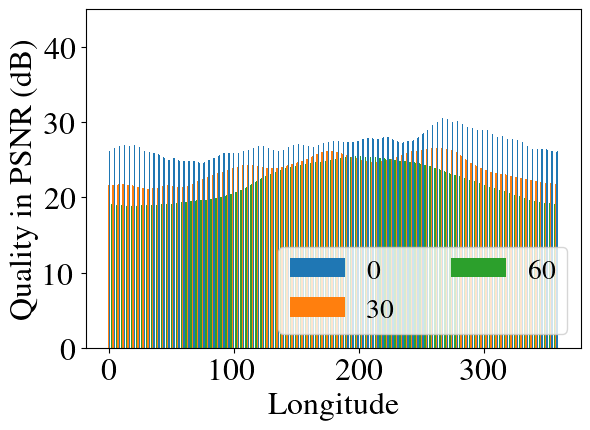

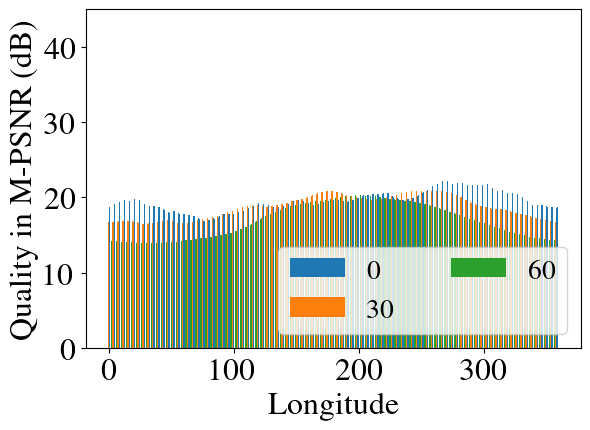

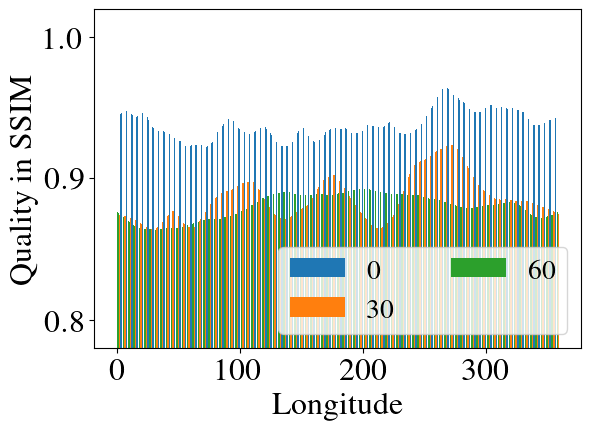

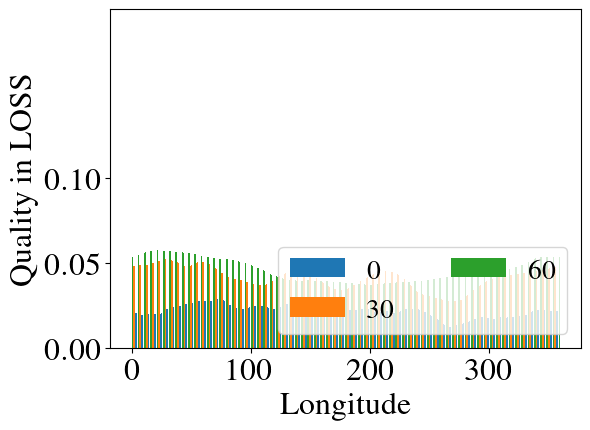

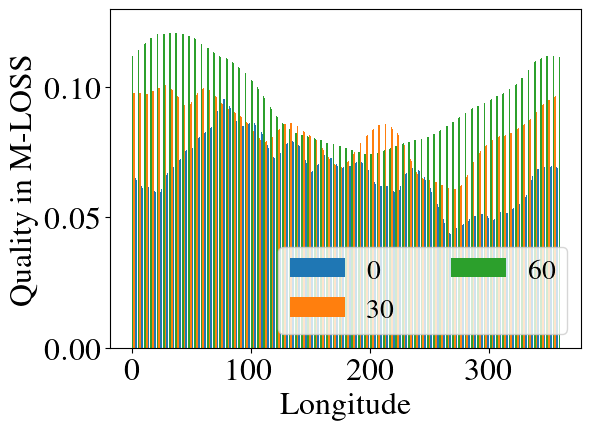

In [142]:
def per_view_visual_quality_deg():
    saveDir = Path(".")/"figs"/f"per_view_visual_quality"
    saveDir.mkdir(parents=True, exist_ok=True)
    
    # training_res_list = [1, 2, 4, 8]
    # gs_res_list = [1, 2, 4, 8]
    # dist_list = [1, 2, 3, 4, 5, 6, 7, 8]

    training_res_list = [1]
    gs_res_list = [1]
    dist_list = [1]
    deg_list = [0, 30, 60]

    data_list = []
    
    for training_res, gs_res in zip(training_res_list, gs_res_list):
        for dist in dist_list:
            for deg in deg_list:
                # file_path = Path("/home/syjintw/Desktop/NUS/lapisgs-output/materials/opacity")/f"materials_res{training_res}"/f"per_view_ours_{dist}x_res{gs_res}.json"
                file_path = Path("/home/syjintw/Desktop/NUS/lapisgs-output/materials/opacity")/f"materials_res{training_res}"/f"per_view_ours_deg{deg}_{dist}x_res{gs_res}.json"
                with open(file_path, "r") as f:
                    data = json.load(f)
                    
                    for view_name in data["ours_30000"]["SSIM"].keys():
                        l = ["materials", training_res, gs_res, dist, deg]
                        l.append(int(view_name.split(".")[0]))  # view idx
                        for metric in ["SSIM", "PSNR", "MASKED_PSNR", "LPIPS", "LOSS", "MASKED_LOSS"]:
                            l.append(data["ours_30000"][metric][view_name])
                        data_list.append(l)

    column_names = ["scene", "training_res", "gs_res", "dist", "deg",
                "view_idx",
                "SSIM", "PSNR", "MASKED_PSNR", "LPIPS",
                "LOSS", "MASKED_LOSS"]
    df = pd.DataFrame(data_list, columns=column_names)
    
    # Step 1: change to plotting format and filter
    df_plot = df.copy()
    # df_plot['encode_size'] = df_plot['encode_size'] * 8 / df_plot['numOf3DGS']
    # df_plot['alg'] = df_plot['alg'].replace(['draco'], 'DRACO')
    
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['drjohnson'], 'DJ')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['playroom'], 'PR')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['train'], 'Train')
    # df_plot['scene_name'] = df_plot['scene_name'].replace(['truck'], 'Truck')
    
    # ---------------------------------------------------------------------------- #
    #                                   Plotting                                   #
    # ---------------------------------------------------------------------------- #
    plt.figure(figsize=figsize)

    # ----------------------------------- PSNR ----------------------------------- #
    x_name = 'view_idx'
    y_name = 'PSNR'
    # y_std_name = 'PSNR_std'
    hue_name = 'deg'

    x_list = sorted(df_plot[x_name].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        # y_std = subset[y_std_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_stds
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            # yerr=yerr,       # Error bars
            label=f'{hue_val}',
            # capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Longitude')
    plt.ylabel('Quality in PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    # plt.xticks(x_indexes, x_list)
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------- M-PSNR ---------------------------------- #
    plt.figure(figsize=figsize)
    x_name = 'view_idx'
    y_name = 'MASKED_PSNR'
    # y_std_name = 'PSNR_std'
    hue_name = 'deg'

    x_list = sorted(df_plot[x_name].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        # y_std = subset[y_std_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_stds
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            # yerr=yerr,       # Error bars
            label=f'{hue_val}',
            # capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Longitude')
    plt.ylabel('Quality in M-PSNR (dB)')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    # plt.xticks(x_indexes, x_list)
    plt.ylim(0, 45)
    plt.yticks([0, 10, 20, 30, 40])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- SSIM ----------------------------------- #
    plt.figure(figsize=figsize)
    x_name = 'view_idx'
    y_name = 'SSIM'
    # y_std_name = 'PSNR_std'
    hue_name = 'deg'

    x_list = sorted(df_plot[x_name].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        # y_std = subset[y_std_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_stds
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            # yerr=yerr,       # Error bars
            label=f'{hue_val}',
            # capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Longitude')
    plt.ylabel('Quality in SSIM')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    # plt.xticks(x_indexes, x_list)
    plt.ylim(0.78, 1.02)
    plt.yticks([0.8, 0.9, 1.0])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # ----------------------------------- LOSS ----------------------------------- #
    plt.figure(figsize=figsize)
    x_name = 'view_idx'
    y_name = 'LOSS'
    # y_std_name = 'PSNR_std'
    hue_name = 'deg'

    x_list = sorted(df_plot[x_name].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        # y_std = subset[y_std_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_stds
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            # yerr=yerr,       # Error bars
            label=f'{hue_val}',
            # capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Longitude')
    plt.ylabel('Quality in LOSS')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    # plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.2)
    plt.yticks([0.0, 0.05, 0.1])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------- MASKED_LOSS ------------------------------- #
    plt.figure(figsize=figsize)
    x_name = 'view_idx'
    y_name = 'MASKED_LOSS'
    # y_std_name = 'PSNR_std'
    hue_name = 'deg'

    x_list = sorted(df_plot[x_name].unique())
    hue_list = sorted(df_plot[hue_name].unique())
    
    x_indexes = np.arange(len(x_list))  # Base positions [0, 1, 2, ...]
    n_groups = len(hue_list)
    # Define Bar Layout
    total_width = 0.85                # Total width of the group of bars
    bar_width = total_width / n_groups
 
    # Plot each group (hue)
    for idx, hue_val in enumerate(hue_list):
        # Filter data for this group
        subset = df_plot[df_plot[hue_name] == hue_val]
        
        # Align data to ensure correct order matches x_indexes
        # (reindexing ensures that if a dist is missing data, it handles it gracefully)
        subset = subset.set_index(x_name).reindex(x_list).reset_index()

        y = subset[y_name]
        # y_std = subset[y_std_name]
        
        # # Calculate 95% CI bounds (Mean +/- 1.96 * Std)
        # yerr = 1.96 * y_stds
        
        # Calculate X position offset
        # Centers the group of bars around the main tick
        offset = (idx - (n_groups - 1) / 2) * bar_width

        plt.bar(
            x_indexes + offset,      # X position
            y,                       # Height
            width=bar_width, 
            # yerr=yerr,       # Error bars
            label=f'{hue_val}',
            # capsize=2.0,
            color=color_palette[idx], alpha=1.0,
            # edgecolor='black' # Sharp edges
        )
        
    # Formatting
    # plt.title(r'PSNR vs Distance by gs\_res (with 95\% CI)') # Usually, we don't write title for figures in papers
    plt.xlabel('Longitude')
    plt.ylabel('Quality in M-LOSS')
    plt.legend(title='', loc='lower right', fontsize="20", ncol=2, markerscale=1)
    
    # Set X-axis ticks to display the actual X values
    # plt.xticks(x_indexes, x_list)
    plt.ylim(0.0, 0.13)
    plt.yticks([0.0, 0.05, 0.1])
    
    # plt.grid(True, linestyle='--', alpha=0.6) # Personlly, don't like grid in paper figures
    plt.tight_layout()
    # plt.savefig(f'{saveDir}/compression_size_scene.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{saveDir}/compression_size_scene.eps', dpi=300, bbox_inches='tight')
    plt.show()

per_view_visual_quality_deg()